# Business Architect Assessment


##  Índice

| Sección | Descripción |
|---------|-------------|
| **0. Setup y Configuración** | Librerías, constantes y estilos |
| **Part 1: Data Analysis** | Análisis de datos transaccionales |
| → 1. Corridor Performance | Top 5 corredores, success rates, avg transaction size |
| → 2. User Behavior | Transacciones por usuario, top 10 users, México vs Colombia |
| → 3. Time Patterns | Patrones por día, hora y tendencia mensual |
| **Part 2: Business Problem-Solving** | Investigación de fallas USD→MXN |
| **Part 3: Strategic Recommendation** | Memo de recomendación para 2026 |

---



### Diccionario de Variables — Transactions

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `transaction_id` | string | Identificador único de transacción |
| `user_id` | string | Identificador del usuario |
| `transaction_date` | date | Fecha de la transacción |
| `transaction_time` | time | Hora de la transacción |
| `corridor` | string | Corredor monetario (ej: USD_MXN) |
| `amount_usd` | float | Monto en USD |
| `status` | string | Estado: success/failed |
| `source_country` | string | País origen |
| `destination_country` | string | País destino |
| `user_segment` | string | Segmento: retail/sme/enterprise |

### Diccionario de Variables — Users

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `user_id` | string | Identificador único del usuario |
| `country` | string | País del usuario (Mexico/Colombia) |
| `user_segment` | string | Segmento: retail/sme/enterprise |
| `registration_date` | date | Fecha de registro |
| `status` | string | Estado: active/inactive |

---

## 0. Setup y Configuración

In [ ]:
# === LIBRERÍAS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suprimir warnings para output limpio
warnings.filterwarnings('ignore')

# === CONFIGURACIÓN DE ESTILO ===
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 100

# Paleta de colores personalizada
COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72', 
    'success': '#28A745',
    'danger': '#DC3545',
    'warning': '#FFC107',
    'info': '#17A2B8',
    'corridors': ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']
}

# === CONSTANTES DE NEGOCIO ===
FEE_RATE = 0.005  # 0.5% fee por transacción exitosa
TARGET_FAIL_RATE = 0.05  # Objetivo: reducir fallas a 5%
DATE_RANGE = ('2025-07', '2025-12')
CORRIDORS = ['USD_MXN', 'USD_COP', 'MXN_COP', 'COP_USD', 'MXN_USD']
WEEKDAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# === FUNCIONES HELPER ===
def calculate_success_rate(df: pd.DataFrame) -> float:
    """Calcula la tasa de éxito para un DataFrame de transacciones."""
    return (df['status'] == 'success').mean() * 100

def calculate_fail_rate(df: pd.DataFrame) -> float:
    """Calcula la tasa de falla para un DataFrame de transacciones."""
    return (df['status'] != 'success').mean() * 100

def calculate_revenue(df: pd.DataFrame, fee_rate: float = FEE_RATE) -> float:
    """Calcula el revenue estimado (fee × monto exitoso)."""
    return df[df['status'] == 'success']['amount_usd'].sum() * fee_rate

def format_currency(value: float) -> str:
    """Formatea un número como moneda USD."""
    return f"${value:,.2f}"

def format_percentage(value: float) -> str:
    """Formatea un número como porcentaje."""
    return f"{value:.2f}%"



## 1. Exploración de Datos

En esta sección cargamos y exploramos los datasets para entender su estructura, tipos de datos, y calidad (valores nulos, duplicados).

In [ ]:
transactions = pd.read_csv('transactions.csv')
users = pd.read_csv('users.csv')


In [ ]:
transactions.head()


,transaction_id,user_id,transaction_date,transaction_time,corridor,amount_usd,status,source_country,destination_country,user_segment
0,TXN_000001,USR_3445,2025-10-15,15:20:38,USD_COP,1753.12,success,US,CO,retail
1,TXN_000002,USR_1185,2025-11-27,12:01:23,USD_COP,2623.00,success,US,CO,retail
2,TXN_000003,USR_2748,2025-09-27,08:26:58,USD_MXN,2309.56,failed,US,MX,retail
3,TXN_000004,USR_3557,2025-12-22,10:43:54,USD_COP,7416.15,success,US,CO,sme
4,TXN_000005,USR_2825,2025-12-14,09:03:24,USD_COP,7328.16,success,US,CO,sme


In [ ]:
transactions.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       50000 non-null  object 
 1   user_id              50000 non-null  object 
 2   transaction_date     50000 non-null  object 
 3   transaction_time     50000 non-null  object 
 4   corridor             50000 non-null  object 
 5   amount_usd           50000 non-null  float64
 6   status               50000 non-null  object 
 7   source_country       50000 non-null  object 
 8   destination_country  50000 non-null  object 
 9   user_segment         50000 non-null  object 
dtypes: float64(1), object(9)
memory usage: 3.8+ MB


In [ ]:
transactions.describe()

,amount_usd
count,50000.000000
mean,5629.369518
std,6174.320362
min,540.030000
25%,1926.680000
50%,3314.120000
75%,6522.440000
max,34993.080000


In [ ]:
transactions.isnull().sum()


transaction_id         0
user_id                0
transaction_date       0
transaction_time       0
corridor               0
amount_usd             0
status                 0
source_country         0
destination_country    0
user_segment           0
dtype: int64

In [ ]:
transactions.duplicated().sum()


np.int64(0)

In [ ]:
transactions.shape


(50000, 10)

In [ ]:
users.head()

,user_id,country,user_segment,registration_date,status
0,USR_0001,Colombia,retail,2024-01-19,active
1,USR_0002,Mexico,retail,2024-09-01,active
2,USR_0003,Colombia,sme,2024-08-28,inactive
3,USR_0004,Mexico,sme,2024-01-23,inactive
4,USR_0005,Colombia,retail,2023-08-17,active


In [ ]:
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            5000 non-null   object
 1   country            5000 non-null   object
 2   user_segment       5000 non-null   object
 3   registration_date  5000 non-null   object
 4   status             5000 non-null   object
dtypes: object(5)
memory usage: 195.4+ KB


In [ ]:
users.describe()


,user_id,country,user_segment,registration_date,status
count,5000,5000,5000,5000,5000
unique,5000,2,3,550,2
top,USR_0001,Mexico,retail,2023-09-24,active
freq,1,2957,2456,19,4243


In [ ]:
users.isnull().sum()


user_id              0
country              0
user_segment         0
registration_date    0
status               0
dtype: int64

In [ ]:
users.duplicated().sum()


np.int64(0)

In [ ]:
users.shape


(5000, 5)

In [ ]:
users.value_counts(['status'])


status  
active      4243
inactive     757
Name: count, dtype: int64

In [ ]:
users.value_counts(['user_segment'])


user_segment
retail          2456
sme             1761
enterprise       783
Name: count, dtype: int64

In [ ]:
users.value_counts(['country'])


country 
Mexico      2957
Colombia    2043
Name: count, dtype: int64

In [ ]:
transactions.head()

,transaction_id,user_id,transaction_date,transaction_time,corridor,amount_usd,status,source_country,destination_country,user_segment
0,TXN_000001,USR_3445,2025-10-15,15:20:38,USD_COP,1753.12,success,US,CO,retail
1,TXN_000002,USR_1185,2025-11-27,12:01:23,USD_COP,2623.00,success,US,CO,retail
2,TXN_000003,USR_2748,2025-09-27,08:26:58,USD_MXN,2309.56,failed,US,MX,retail
3,TXN_000004,USR_3557,2025-12-22,10:43:54,USD_COP,7416.15,success,US,CO,sme
4,TXN_000005,USR_2825,2025-12-14,09:03:24,USD_COP,7328.16,success,US,CO,sme


# PART 1: DATA ANALYSIS



---

## Preparación de Datos

En esta sección preparamos los datos para el análisis, incluyendo conversión de tipos y creación de features temporales.


In [ ]:
transactions['transaction_date']=pd.to_datetime(transactions['transaction_date'])

# Cambiar los dias y tiempos en formatos datetime
transactions['transaction_time'] = pd.to_datetime(
    transactions['transaction_time'],
    format="%H:%M:%S"
)

In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   transaction_id       50000 non-null  object        
 1   user_id              50000 non-null  object        
 2   transaction_date     50000 non-null  datetime64[ns]
 3   transaction_time     50000 non-null  datetime64[ns]
 4   corridor             50000 non-null  object        
 5   amount_usd           50000 non-null  float64       
 6   status               50000 non-null  object        
 7   source_country       50000 non-null  object        
 8   destination_country  50000 non-null  object        
 9   user_segment         50000 non-null  object        
dtypes: datetime64[ns](2), float64(1), object(7)
memory usage: 3.8+ MB


## 1. Corridor Performance

**Questions to answer:**
- What are the top 5 payment corridors by transaction volume?
- What are the top 5 corridors by transaction value (total USD)?
- Which corridors have the highest success rates?
- Calculate average transaction size by corridor


In [ ]:
transactions.head()

,transaction_id,user_id,transaction_date,transaction_time,corridor,amount_usd,status,source_country,destination_country,user_segment
0,TXN_000001,USR_3445,2025-10-15,1900-01-01 15:20:38,USD_COP,1753.12,success,US,CO,retail
1,TXN_000002,USR_1185,2025-11-27,1900-01-01 12:01:23,USD_COP,2623.00,success,US,CO,retail
2,TXN_000003,USR_2748,2025-09-27,1900-01-01 08:26:58,USD_MXN,2309.56,failed,US,MX,retail
3,TXN_000004,USR_3557,2025-12-22,1900-01-01 10:43:54,USD_COP,7416.15,success,US,CO,sme
4,TXN_000005,USR_2825,2025-12-14,1900-01-01 09:03:24,USD_COP,7328.16,success,US,CO,sme


In [ ]:
#Tip 5 corredor por volumen(cantidad) de transaccion 
corredor_volumen = transactions.groupby('corridor')['amount_usd'].size().sort_values(ascending=False)
print("Top 5 corredores por volumn de transacciones:")
# dio igual el count que el size ya que el coint es Nan pero no hay 
print(corredor_volumen.head())


Top 5 corredores por volumn de transacciones:
corridor
USD_MXN    17407
USD_COP    15066
MXN_COP     7600
COP_USD     5988
MXN_USD     3939
Name: amount_usd, dtype: int64


In [ ]:
porcentajes_pregunta1=(corredor_volumen.head()/len(transactions)*100)
print(f"Porcentaje del total : {porcentajes_pregunta1}")

Porcentaje del total : corridor
USD_MXN    34.814
USD_COP    30.132
MXN_COP    15.200
COP_USD    11.976
MXN_USD     7.878
Name: amount_usd, dtype: float64


In [ ]:
# Top 5 corredores por valor total (USD)
corridor_value = transactions.groupby('corridor')['amount_usd'].sum().sort_values(ascending=False)
print("Top 5 corredores por VALOR TOTAL (USD):")
print(corridor_value.head())
print(f"\nValor total (millones USD): {(corridor_value.head().sum() / 1000000):.2f}M")


Top 5 corredores por VALOR TOTAL (USD):
corridor
USD_MXN    1.265671e+08
USD_COP    7.781885e+07
MXN_COP    2.752018e+07
COP_USD    2.691452e+07
MXN_USD    2.264784e+07
Name: amount_usd, dtype: float64

Valor total (millones USD): 281.47M


In [ ]:
# Tasa de éxito por corredor (%): ¿qué corredores tienen mayor success rate?

def corridor_exito(d):
    return (d == 'success').mean() * 100


corridor_successdf = transactions.groupby('corridor')['status']

corridor_success = corridor_successdf.apply(corridor_exito).sort_values(ascending=False)

print(f"Tasas de éxito por corredor:{corridor_success.round(2)}")



Tasas de éxito por corredor:corridor
COP_USD    95.72
MXN_USD    95.28
USD_COP    94.90
MXN_COP    94.83
USD_MXN    81.75
Name: status, dtype: float64


In [ ]:
# Tamaño promedio de transacción por corredor
promedio_corredor = transactions.groupby('corridor')['amount_usd'].mean().sort_values(ascending=False)
print(f"Tamaño promedio de transacción por corredor (USD): {promedio_corredor.round(2)}")


Tamaño promedio de transacción por corredor (USD): corridor
USD_MXN    7271.05
MXN_USD    5749.64
USD_COP    5165.20
COP_USD    4494.74
MXN_COP    3621.08
Name: amount_usd, dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/fig_corridor_performance.png'

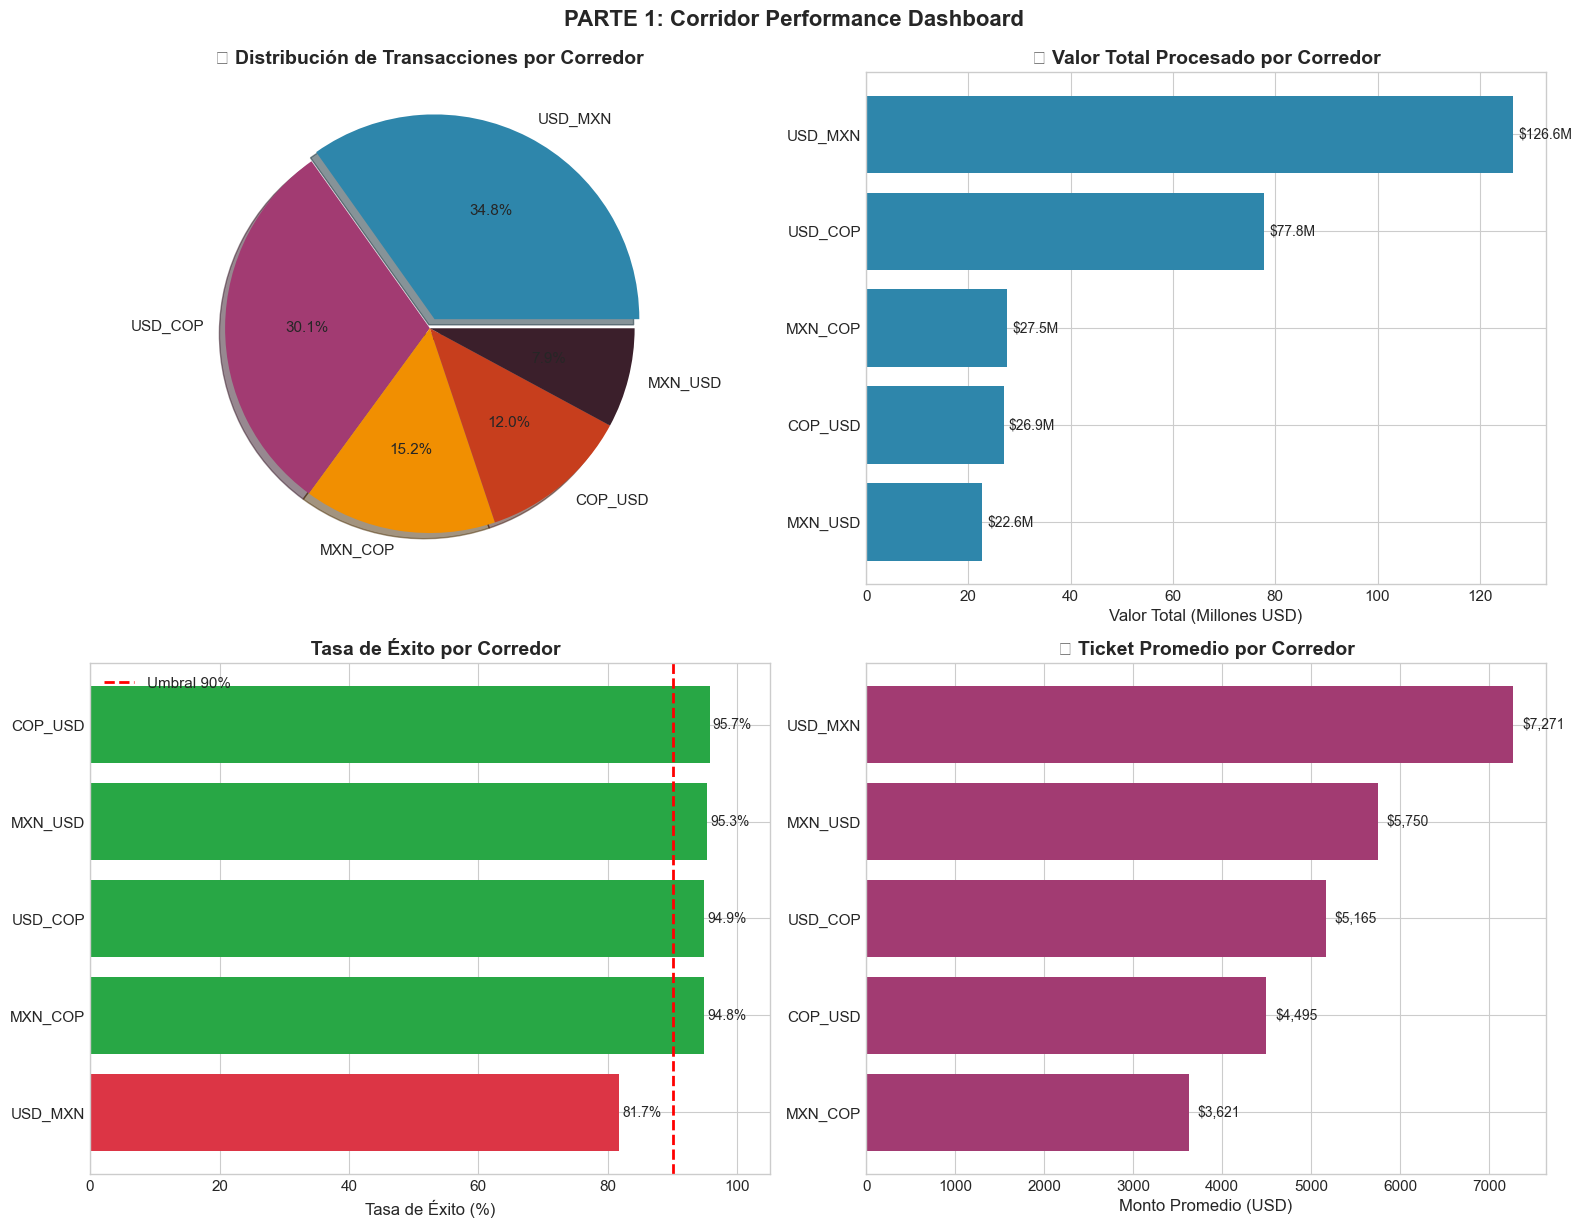

In [ ]:
# === VISUALIZACIONES: Corridor Performance ===

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución de volumen por corredor (pie chart)
ax1 = axes[0, 0]
corridor_counts = transactions['corridor'].value_counts()
colors = COLORS['corridors']
wedges, texts, autotexts = ax1.pie(
    corridor_counts.values, 
    labels=corridor_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.05 if c == 'USD_MXN' else 0 for c in corridor_counts.index],
    shadow=True
)
ax1.set_title(' Distribución de Transacciones por Corredor', fontsize=14, fontweight='bold')

# 2. Valor total por corredor (bar chart horizontal)
ax2 = axes[0, 1]
corridor_value = transactions.groupby('corridor')['amount_usd'].sum().sort_values() / 1e6
bars = ax2.barh(corridor_value.index, corridor_value.values, color=COLORS['primary'])
ax2.set_xlabel('Valor Total (Millones USD)')
ax2.set_title(' Valor Total Procesado por Corredor', fontsize=14, fontweight='bold')
for bar, val in zip(bars, corridor_value.values):
    ax2.text(val + 1, bar.get_y() + bar.get_height()/2, f'${val:.1f}M', va='center', fontsize=10)

# 3. Tasa de éxito por corredor (bar chart con línea de referencia)
ax3 = axes[1, 0]
success_rates = transactions.groupby('corridor')['status'].apply(lambda x: (x == 'success').mean() * 100).sort_values()
bar_colors = [COLORS['danger'] if rate < 90 else COLORS['success'] for rate in success_rates.values]
bars = ax3.barh(success_rates.index, success_rates.values, color=bar_colors)
ax3.axvline(x=90, color='red', linestyle='--', linewidth=2, label='Umbral 90%')
ax3.set_xlabel('Tasa de Éxito (%)')
ax3.set_title('  Tasa de Éxito por Corredor', fontsize=14, fontweight='bold')
ax3.legend()
for bar, val in zip(bars, success_rates.values):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)
ax3.set_xlim(0, 105)

# 4. Ticket promedio por corredor
ax4 = axes[1, 1]
avg_ticket = transactions.groupby('corridor')['amount_usd'].mean().sort_values()
bars = ax4.barh(avg_ticket.index, avg_ticket.values, color=COLORS['secondary'])
ax4.set_xlabel('Monto Promedio (USD)')
ax4.set_title(' Ticket Promedio por Corredor', fontsize=14, fontweight='bold')
for bar, val in zip(bars, avg_ticket.values):
    ax4.text(val + 100, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.suptitle('PARTE 1: Corridor Performance Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('outputs/fig_corridor_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("  Figura guardada: outputs/fig_corridor_performance.png")

## 2. User Behavior

**Questions to answer:**
- What's the average number of transactions per user?
- Identify the top 10 users by transaction volume
- How does user behavior differ between Mexico and Colombia?

In [ ]:
# Promedio de transacciones por usuario
promedioTransacciones = transactions.groupby('user_id').size().mean()
print(f"Promedio de transacciones por usuario: {promedioTransacciones}")

Promedio de transacciones por usuario: 10.0


In [ ]:
# Top 10 usuarios por VOLUMEN de transacciones (count)
top_usuarios_volumen = transactions.groupby('user_id').size().sort_values(ascending=False)
print(f"Top 10 usuaruos por volumen de transacciones: {top_usuarios_volumen.head(10)}")

Top 10 usuaruos por volumen de transacciones: user_id
USR_1798    21
USR_4823    21
USR_1843    21
USR_4714    21
USR_1186    20
USR_4164    20
USR_1853    20
USR_0336    20
USR_2234    20
USR_3778    20
dtype: int64


In [ ]:
#Enriquecer por pais,user segment, status para el usuario 
top10_users = top_usuarios_volumen.head(10).reset_index(name='num_transactions') # Para hacerlo un df
top10_users = top10_users.merge(users[['user_id','country','user_segment','status']], on='user_id', how='left')
top10_users

,user_id,num_transactions,country,user_segment,status
0,USR_1798,21,Mexico,enterprise,active
1,USR_4823,21,Mexico,retail,active
2,USR_1843,21,Mexico,sme,active
3,USR_4714,21,Mexico,retail,active
4,USR_1186,20,Colombia,retail,active
5,USR_4164,20,Mexico,retail,active
6,USR_1853,20,Colombia,retail,active
7,USR_0336,20,Colombia,enterprise,active
8,USR_2234,20,Mexico,sme,active
9,USR_3778,20,Colombia,sme,active


In [ ]:
#How does user behavior differ between Mexico and Colombia?


transactions_with_country = transactions.merge(
    users[['user_id', 'country']], 
    on='user_id', 
    how='left' # Para no perder si es que no existe transaccion para ese usuario 

)

print(f"Total transacciones: {len(transactions_with_country)}")
print(f"Transacciones con país: {transactions_with_country['country'].notna().sum()}")
print(f"\nDistribución por país:")
print(transactions_with_country['country'].value_counts())

Total transacciones: 50000
Transacciones con país: 50000

Distribución por país:
country
Mexico      29526
Colombia    20474
Name: count, dtype: int64


In [ ]:
# Contar transacciones por usuario por país
transacciones_por_usuario_pais = transactions_with_country.groupby(['user_id', 'country']).size().reset_index(name='num_transacciones')

# Promedio por país
promedio_por_pais = transacciones_por_usuario_pais.groupby('country')['num_transacciones'].mean()

# Tasa de éxito por país (%): serie numérica
success_rate = transactions_with_country.groupby('country')['status'].apply(corridor_exito).sort_values(ascending=False)

# Distribucion por segmento y pais (conteos)
segment_distribution = transactions_with_country.groupby(['country', 'user_segment']).size().unstack(fill_value=0)

# Porcentaje de transacciones por segmento y pais (% dentro de cada país)
segement_pct = (
    transactions_with_country.groupby(['country', 'user_segment'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum() * 100)
    .unstack(fill_value=0)
)

# Resumen comparativo (tabla final)
comparison_summary = pd.DataFrame({
    'Avg_Transaction_Size_USD': transactions_with_country.groupby('country')['amount_usd'].mean(),
    'Total_Transactions': transactions_with_country.groupby('country').size(),
    'Total_Value_USD': transactions_with_country.groupby('country')['amount_usd'].sum()
})


In [ ]:
print('--- México vs Colombia: comportamiento de usuarios ---')

print('\nPromedio de transacciones por usuario (por país):')
print(promedio_por_pais.round(2))

print('\nTasa de éxito por país (%):')
print(success_rate.round(2))

print('\nDistribución de transacciones por segmento (conteos):')
print(segment_distribution)

print('\nDistribución de transacciones por segmento (% dentro de cada país):')
print(segement_pct.round(2))

print('\nResumen comparativo (tabla):')
print(comparison_summary.round(2))


--- México vs Colombia: comportamiento de usuarios ---

Promedio de transacciones por usuario (por país):
country
Colombia    10.02
Mexico       9.99
Name: num_transacciones, dtype: float64

Tasa de éxito por país (%):
country
Colombia    90.46
Mexico      90.42
Name: status, dtype: float64

Distribución de transacciones por segmento (conteos):
user_segment  enterprise  retail    sme
country                                
Colombia            3122   10182   7170
Mexico              4409   14682  10435

Distribución de transacciones por segmento (% dentro de cada país):
user_segment       enterprise  retail    sme
country  country                            
Colombia Colombia       15.25   49.73  35.02
Mexico   Mexico         14.93   49.73  35.34

Resumen comparativo (tabla):
          Avg_Transaction_Size_USD  Total_Transactions  Total_Value_USD
country                                                                
Colombia                   5678.59               20474     1.162634e+0

📊 ANÁLISIS AVANZADO DE USUARIOS

1️⃣ COMPORTAMIENTO POR STATUS DE USUARIO
----------------------------------------
             total_users  total_transactions  total_value_usd  avg_ticket  \
status_user                                                                 
active              4243               42474     2.394620e+08     5637.85   
inactive             757                7526     4.200648e+07     5581.52   

             success_rate  tx_per_user  
status_user                             
active              90.42        10.01  
inactive            90.57         9.94  

2️⃣ COMPORTAMIENTO POR ANTIGÜEDAD DEL USUARIO
----------------------------------------
               total_users  total_transactions  total_value_usd  avg_ticket  \
tenure_bucket                                                                 
<6 meses                 0                   0     0.000000e+00         NaN   
6-12 meses              29                 287     1.628496e+06     5674.20   
1-2 años

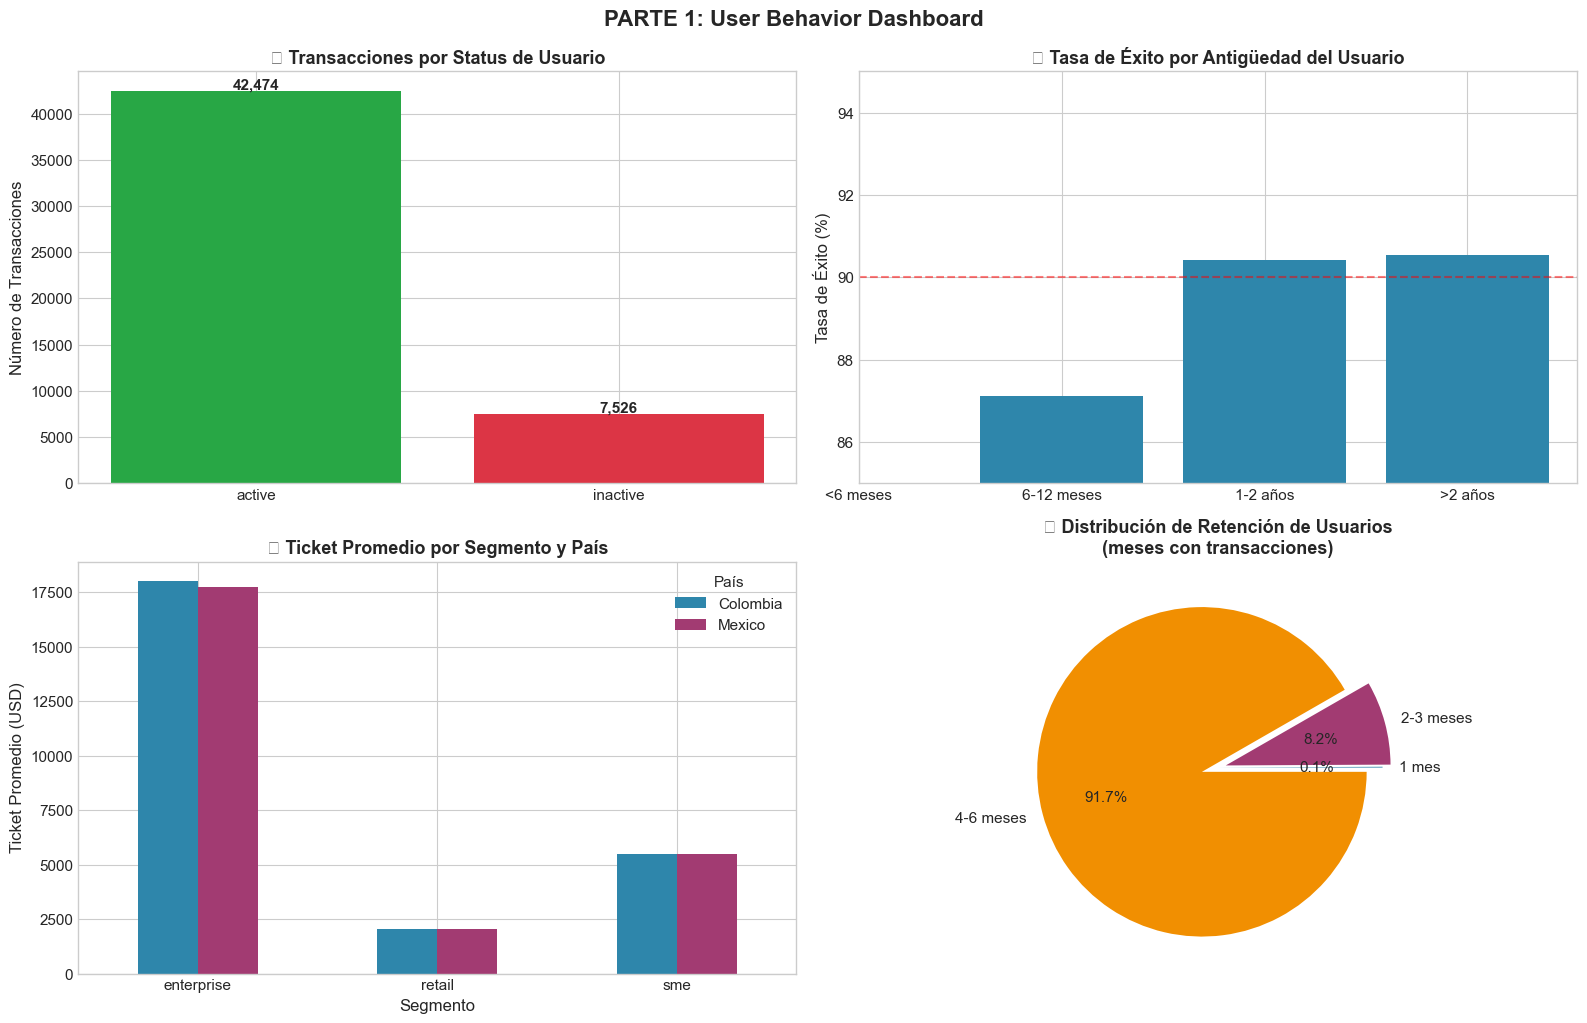


  Figura guardada: outputs/fig_user_behavior.png


In [ ]:
# === ANÁLISIS AVANZADO DE USUARIOS (Integración users.csv) ===

# Preparar datos de usuarios
users_prep = users.copy()
users_prep['registration_date'] = pd.to_datetime(users_prep['registration_date'])
users_prep['user_tenure_days'] = (pd.Timestamp('2025-12-31') - users_prep['registration_date']).dt.days
users_prep['tenure_bucket'] = pd.cut(
    users_prep['user_tenure_days'], 
    bins=[0, 180, 365, 730, float('inf')],
    labels=['<6 meses', '6-12 meses', '1-2 años', '>2 años']
)

# Merge transactions con users
tx_enriched = transactions.merge(
    users_prep[['user_id', 'country', 'status', 'tenure_bucket', 'user_tenure_days']], 
    on='user_id', 
    how='left',
    suffixes=('_tx', '_user')
)

print("="*60)
print(" ANÁLISIS AVANZADO DE USUARIOS")
print("="*60)

# 1. Comportamiento por Status de Usuario (Active vs Inactive)
print("\n1️⃣ COMPORTAMIENTO POR STATUS DE USUARIO")
print("-"*40)
user_status_analysis = tx_enriched.groupby('status_user').agg(
    total_users=('user_id', 'nunique'),
    total_transactions=('transaction_id', 'count'),
    total_value_usd=('amount_usd', 'sum'),
    avg_ticket=('amount_usd', 'mean'),
    success_rate=('status_tx', lambda x: (x == 'success').mean() * 100)
).round(2)
user_status_analysis['tx_per_user'] = (user_status_analysis['total_transactions'] / user_status_analysis['total_users']).round(2)
print(user_status_analysis)

# 2. Comportamiento por Antigüedad del Usuario
print("\n2️⃣ COMPORTAMIENTO POR ANTIGÜEDAD DEL USUARIO")
print("-"*40)
tenure_analysis = tx_enriched.groupby('tenure_bucket').agg(
    total_users=('user_id', 'nunique'),
    total_transactions=('transaction_id', 'count'),
    total_value_usd=('amount_usd', 'sum'),
    avg_ticket=('amount_usd', 'mean'),
    success_rate=('status_tx', lambda x: (x == 'success').mean() * 100)
).round(2)
tenure_analysis['tx_per_user'] = (tenure_analysis['total_transactions'] / tenure_analysis['total_users']).round(2)
print(tenure_analysis)

# 3. Usuarios por Corredor Preferido
print("\n3️⃣ CORREDOR PREFERIDO POR SEGMENTO DE USUARIO")
print("-"*40)
preferred_corridor = tx_enriched.groupby(['user_segment', 'corridor']).size().unstack(fill_value=0)
print(preferred_corridor)

# 4. Retención: Usuarios con transacciones en múltiples meses
print("\n4️⃣ ANÁLISIS DE RETENCIÓN")
print("-"*40)
tx_enriched['tx_month'] = tx_enriched['transaction_date'].dt.to_period('M')
user_months = tx_enriched.groupby('user_id')['tx_month'].nunique()
retention_buckets = pd.cut(user_months, bins=[0, 1, 3, 6], labels=['1 mes', '2-3 meses', '4-6 meses'])
retention_dist = retention_buckets.value_counts().sort_index()
print(f"Distribución de usuarios por meses activos:")
print(retention_dist)
print(f"\nUsuarios con transacciones en 4+ meses (alta retención): {(user_months >= 4).sum()} ({(user_months >= 4).mean()*100:.1f}%)")

# === VISUALIZACIÓN: User Behavior Dashboard ===
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Transacciones por Status de Usuario
ax1 = axes[0, 0]
status_counts = tx_enriched.groupby('status_user').size()
colors = [COLORS['success'] if s == 'active' else COLORS['danger'] for s in status_counts.index]
bars = ax1.bar(status_counts.index, status_counts.values, color=colors)
ax1.set_ylabel('Número de Transacciones')
ax1.set_title(' Transacciones por Status de Usuario', fontsize=13, fontweight='bold')
for bar, val in zip(bars, status_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 200, f'{val:,}', ha='center', fontsize=11, fontweight='bold')

# 2. Success Rate por Antigüedad
ax2 = axes[0, 1]
tenure_success = tx_enriched.groupby('tenure_bucket')['status_tx'].apply(lambda x: (x == 'success').mean() * 100)
bars = ax2.bar(range(len(tenure_success)), tenure_success.values, color=COLORS['primary'])
ax2.set_xticks(range(len(tenure_success)))
ax2.set_xticklabels(tenure_success.index)
ax2.set_ylabel('Tasa de Éxito (%)')
ax2.set_title(' Tasa de Éxito por Antigüedad del Usuario', fontsize=13, fontweight='bold')
ax2.set_ylim(85, 95)
ax2.axhline(y=90, color='red', linestyle='--', alpha=0.5)

# 3. Valor Promedio por Segmento y País
ax3 = axes[1, 0]
segment_country = tx_enriched.groupby(['user_segment', 'country'])['amount_usd'].mean().unstack()
segment_country.plot(kind='bar', ax=ax3, color=[COLORS['primary'], COLORS['secondary']])
ax3.set_ylabel('Ticket Promedio (USD)')
ax3.set_xlabel('Segmento')
ax3.set_title(' Ticket Promedio por Segmento y País', fontsize=13, fontweight='bold')
ax3.legend(title='País')
ax3.tick_params(axis='x', rotation=0)

# 4. Distribución de Retención
ax4 = axes[1, 1]
retention_dist.plot(kind='pie', ax=ax4, autopct='%1.1f%%', colors=COLORS['corridors'][:3], explode=[0, 0.05, 0.1])
ax4.set_title(' Distribución de Retención de Usuarios\n(meses con transacciones)', fontsize=13, fontweight='bold')
ax4.set_ylabel('')

plt.tight_layout()
plt.suptitle('PARTE 1: User Behavior Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('outputs/fig_user_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  Figura guardada: outputs/fig_user_behavior.png")

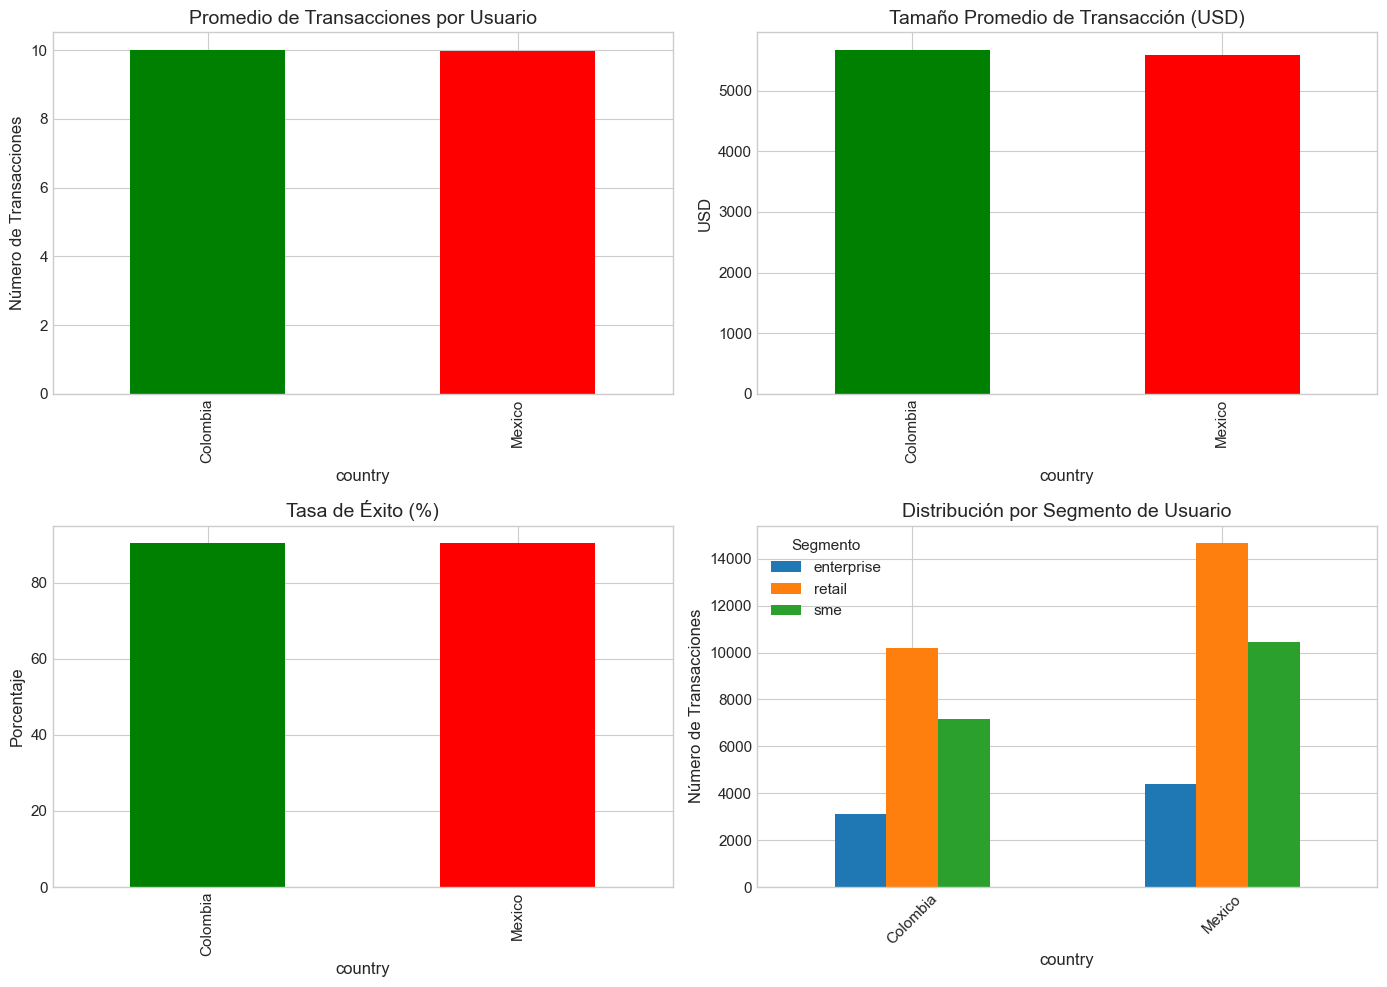

In [ ]:
# Gráfico comparativo
# Nota: definimos avg_transaction_size aquí para evitar NameError
avg_transaction_size = transactions_with_country.groupby('country')['amount_usd'].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Promedio de transacciones por usuario
promedio_por_pais.plot(kind='bar', ax=axes[0,0], color=['green', 'red'])
axes[0,0].set_title('Promedio de Transacciones por Usuario')
axes[0,0].set_ylabel('Número de Transacciones')

# 2. Tamaño promedio de transacción
avg_transaction_size.plot(kind='bar', ax=axes[0,1], color=['green', 'red'])
axes[0,1].set_title('Tamaño Promedio de Transacción (USD)')
axes[0,1].set_ylabel('USD')

# 3. Tasa de éxito
success_rate.plot(kind='bar', ax=axes[1,0], color=['green', 'red'])
axes[1,0].set_title('Tasa de Éxito (%)')
axes[1,0].set_ylabel('Porcentaje')

# 4. Distribución por segmento
segment_distribution.plot(kind='bar', ax=axes[1,1], stacked=False)
axes[1,1].set_title('Distribución por Segmento de Usuario')
axes[1,1].set_ylabel('Número de Transacciones')
axes[1,1].legend(title='Segmento')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Time Patterns

**Questions to answer:**
- What days of the week have the highest transaction volume?
- Are there any notable hourly patterns?
- Has transaction volume been growing or declining over the 6-month period?


In [ ]:
# Features de tiempo
transactions['day_of_week'] = transactions['transaction_date'].dt.day_name()
transactions['hour'] = transactions['transaction_time'].dt.hour
transactions['month'] = transactions['transaction_date'].dt.to_period('M').astype(str)

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']


Volumen por día de la semana:
day_of_week
Monday       7110
Tuesday      7337
Wednesday    7190
Thursday     6998
Friday       7126
Saturday     7040
Sunday       7199
dtype: int64

Día con mayor volumen: Tuesday (7,337 transacciones)


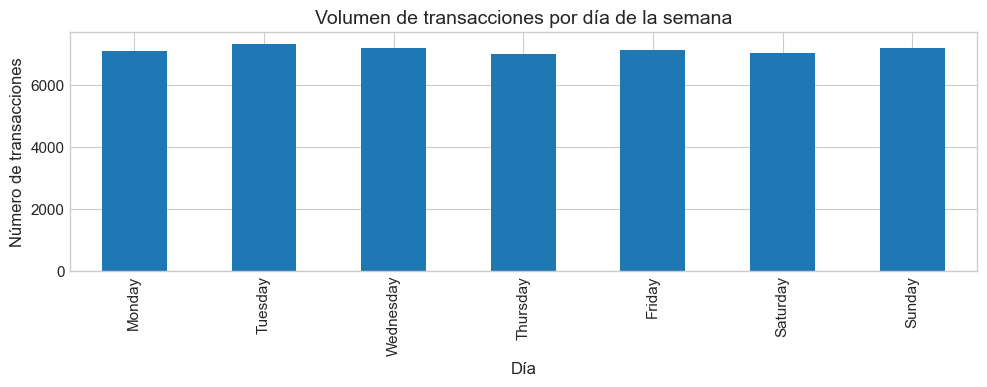

In [ ]:
# 3.1 ¿Qué días de la semana tienen mayor volumen?
dow_volume = transactions.groupby('day_of_week').size().reindex(weekday_order)
print('Volumen por día de la semana:')
print(dow_volume)

print(f"\nDía con mayor volumen: {dow_volume.idxmax()} ({int(dow_volume.max()):,} transacciones)")

# Visualización
ax = dow_volume.plot(kind='bar', figsize=(10,4), title='Volumen de transacciones por día de la semana')
ax.set_xlabel('Día')
ax.set_ylabel('Número de transacciones')
plt.tight_layout()
plt.show()


Volumen por hora (0-23):
hour
8     4205
9     4106
10    4304
11    4128
12    4167
13    4227
14    4209
15    4139
16    4102
17    4116
18    4128
19    4169
dtype: int64

Hora con mayor volumen: 10 (4,304 transacciones)


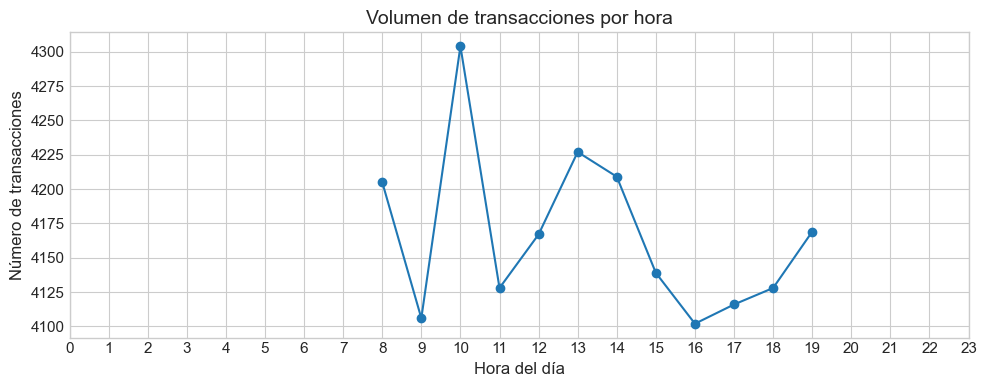

In [ ]:
# 3.2 ¿Patrones por hora?
hourly_volume = transactions.groupby('hour').size().sort_index()
print('Volumen por hora (0-23):')
print(hourly_volume)

print(f"\nHora con mayor volumen: {int(hourly_volume.idxmax())} ({int(hourly_volume.max()):,} transacciones)")

ax = hourly_volume.plot(kind='line', marker='o', figsize=(10,4), title='Volumen de transacciones por hora')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Número de transacciones')
ax.set_xticks(range(0,24))
plt.tight_layout()
plt.show()


Volumen mensual:
month
2025-07    8479
2025-08    8524
2025-09    8082
2025-10    8395
2025-11    8336
2025-12    8184
dtype: int64

Cambio de 2025-07 a 2025-12: -3.48%


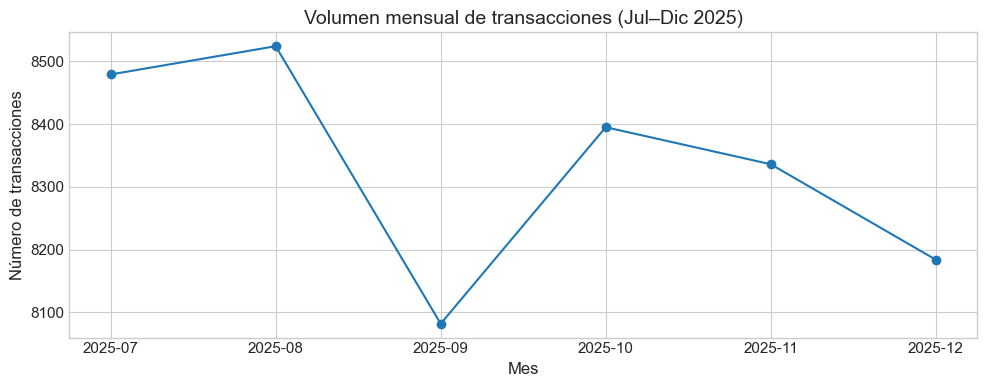

In [ ]:
# 3.3 ¿Crecimiento o declive en 6 meses?
monthly_volume = transactions.groupby('month').size().sort_index()
print('Volumen mensual:')
print(monthly_volume)

first_month = monthly_volume.index[0]
last_month = monthly_volume.index[-1]
trend_pct = (monthly_volume.loc[last_month] - monthly_volume.loc[first_month]) / monthly_volume.loc[first_month] * 100
print(f"\nCambio de {first_month} a {last_month}: {trend_pct:.2f}%")

ax = monthly_volume.plot(kind='line', marker='o', figsize=(10,4), title='Volumen mensual de transacciones (Jul–Dic 2025)')
ax.set_xlabel('Mes')
ax.set_ylabel('Número de transacciones')
plt.tight_layout()
plt.show()


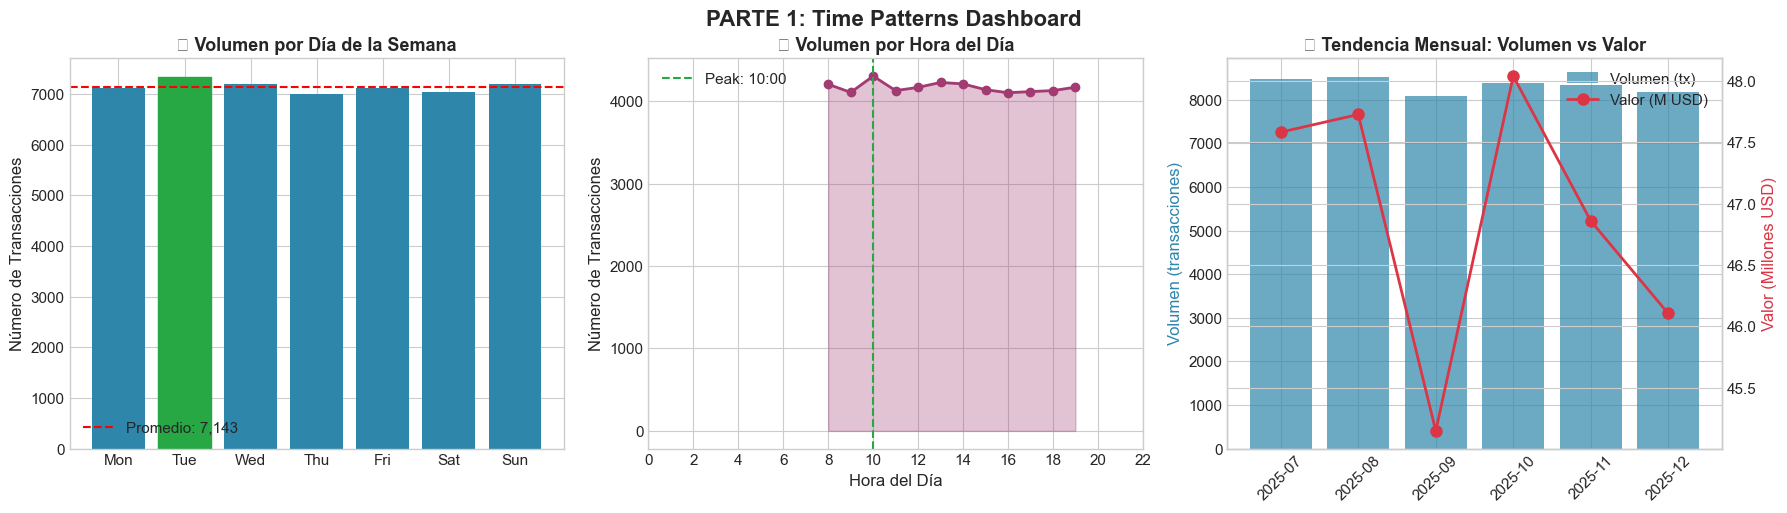

  Figura guardada: outputs/fig_time_patterns.png


In [ ]:
# === VISUALIZACIONES: Time Patterns ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Volumen por día de la semana
ax1 = axes[0]
dow_volume = transactions.groupby('day_of_week').size().reindex(WEEKDAY_ORDER)
bars = ax1.bar(range(len(WEEKDAY_ORDER)), dow_volume.values, color=COLORS['primary'])
ax1.set_xticks(range(len(WEEKDAY_ORDER)))
ax1.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax1.set_ylabel('Número de Transacciones')
ax1.set_title(' Volumen por Día de la Semana', fontsize=13, fontweight='bold')
# Highlight max day
max_idx = dow_volume.values.argmax()
bars[max_idx].set_color(COLORS['success'])
ax1.axhline(y=dow_volume.mean(), color='red', linestyle='--', label=f'Promedio: {dow_volume.mean():,.0f}')
ax1.legend()

# 2. Volumen por hora
ax2 = axes[1]
hourly_volume = transactions.groupby(transactions['transaction_time'].dt.hour).size()
ax2.plot(hourly_volume.index, hourly_volume.values, marker='o', linewidth=2, color=COLORS['secondary'])
ax2.fill_between(hourly_volume.index, hourly_volume.values, alpha=0.3, color=COLORS['secondary'])
ax2.set_xlabel('Hora del Día')
ax2.set_ylabel('Número de Transacciones')
ax2.set_title('⏰ Volumen por Hora del Día', fontsize=13, fontweight='bold')
ax2.set_xticks(range(0, 24, 2))
# Highlight peak hour
peak_hour = hourly_volume.idxmax()
ax2.axvline(x=peak_hour, color=COLORS['success'], linestyle='--', label=f'Peak: {peak_hour}:00')
ax2.legend()

# 3. Tendencia mensual
ax3 = axes[2]
transactions['month'] = transactions['transaction_date'].dt.to_period('M').astype(str)
monthly_data = transactions.groupby('month').agg(
    volume=('transaction_id', 'count'),
    value=('amount_usd', 'sum')
).reset_index()

ax3_twin = ax3.twinx()
line1 = ax3.bar(range(len(monthly_data)), monthly_data['volume'].values, alpha=0.7, color=COLORS['primary'], label='Volumen (tx)')
line2 = ax3_twin.plot(range(len(monthly_data)), monthly_data['value'].values / 1e6, 'o-', color=COLORS['danger'], linewidth=2, markersize=8, label='Valor (M USD)')

ax3.set_xticks(range(len(monthly_data)))
ax3.set_xticklabels(monthly_data['month'].values, rotation=45)
ax3.set_ylabel('Volumen (transacciones)', color=COLORS['primary'])
ax3_twin.set_ylabel('Valor (Millones USD)', color=COLORS['danger'])
ax3.set_title(' Tendencia Mensual: Volumen vs Valor', fontsize=13, fontweight='bold')

# Legend
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.suptitle('PARTE 1: Time Patterns Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('outputs/fig_time_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print("  Figura guardada: outputs/fig_time_patterns.png")

#  PART 2: BUSINESS PROBLEM-SOLVING — USD→MXN Failure Investigation

---

**Problema:** El corredor USD→MXN presenta una tasa de falla anormalmente alta.

**Estructura de análisis:**

| Sección | Pregunta |
|---------|----------|
| **2.1 Root Cause Analysis** | |
| → 2.1.1 | What patterns do you see in the failed transactions? |
| → 2.1.2 | What are 3 possible root causes for the high failure rate? |
| → 2.1.3 | How would you validate which root cause is correct? |
| **2.2 Business Impact** | |
| → 2.2.1 | Estimate the monthly revenue loss (fee = 0.5%) |
| → 2.2.2 | If failure rate drops to 5%, what is the monthly revenue gain? |


## 2.1 Root Cause Analysis

### 2.1.1 What patterns do you see in the failed transactions?

Analizamos los patrones de falla por múltiples dimensiones:
- **Contexto general:** Comparación USD→MXN vs promedio
- **Por segmento de usuario:** Enterprise, SME, Retail
- **Por tamaño de transacción:** Bins de monto (0-1k, 1k-5k, 5k-10k, 10k-20k, >20k)
- **Por día de la semana:** Patrón temporal

In [ ]:
# 2.1 Contexto: ¿qué tan malo es USD_MXN vs el promedio?
overall_fail_rate = (transactions['status'] != 'success').mean() * 100
usd_mxn = transactions[transactions['corridor'] == 'USD_MXN'].copy()
usd_mxn_fail_rate = (usd_mxn['status'] != 'success').mean() * 100

print(f"Falla promedio (todas las transacciones): {overall_fail_rate:.2f}%")
print(f"Falla en USD_MXN: {usd_mxn_fail_rate:.2f}%")
print(f"Diferencia (pp): {usd_mxn_fail_rate - overall_fail_rate:.2f} pp")
print(f"Total transacciones USD_MXN: {len(usd_mxn):,}")


Falla promedio (todas las transacciones): 9.56%
Falla en USD_MXN: 18.25%
Diferencia (pp): 8.69 pp
Total transacciones USD_MXN: 17,407


fallo por segmento: user_segment
enterprise    23.90
retail        19.50
sme           14.12
Name: status, dtype: float64
Falla por tamaño (bins):            transaction_count  fail_rate_%
amount_bin                                
<=1k                        0          NaN
1k-2.5k                  3960        19.75
2.5k-5k                  5948        17.97
5k-10k                   4409        13.70
10k-20k                  1437        22.83
>20k                     1653        23.84
Falla por día de la semana (%): day_of_week
Monday       18.81
Tuesday      18.94
Wednesday    17.03
Thursday     18.76
Friday       18.36
Saturday     18.28
Sunday       17.56
Name: status, dtype: float64 


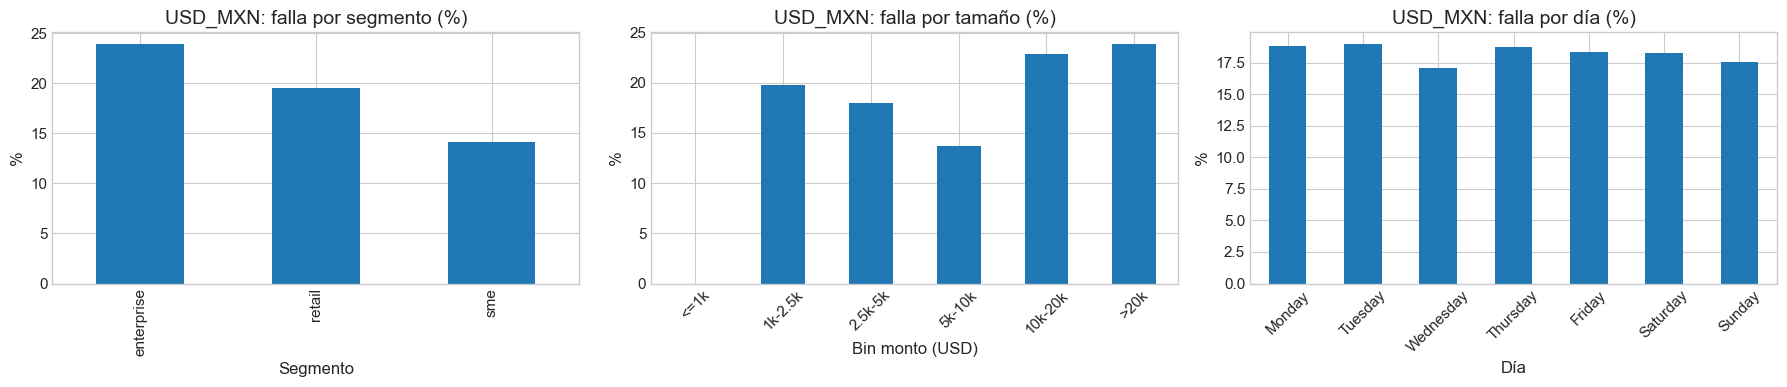

In [ ]:
# 2.2 Patrones de falla: segmento, tamaño de transacción, día

# Falla del succes
def fallo(s):
    return (s != "success").mean() * 100


fail_by_segment = (
    usd_mxn.groupby("user_segment")["status"].apply(fallo).sort_values(ascending=False)
)
print(f"fallo por segmento: {fail_by_segment.round(2)}")

# Falla por tamaño (bins)
bins = [0, 1000, 2500, 5000, 10000, 20000, float("inf")]
labels = ["<=1k", "1k-2.5k", "2.5k-5k", "5k-10k", "10k-20k", ">20k"]
usd_mxn["amount_bin"] = pd.cut(
    usd_mxn["amount_usd"], bins=bins, labels=labels, include_lowest=True
)
# El cut para poder clasificar cada transaccion segun su amount usd.

# tasa de fallo por rango
fail_by_bin = usd_mxn.groupby("amount_bin")["status"].apply(fallo).reindex(labels)
# conteo de transacciones por rango
count_by_bin = usd_mxn.groupby("amount_bin").size().reindex(labels)

bin_table = pd.DataFrame(
    {"transaction_count": count_by_bin, "fail_rate_%": fail_by_bin}
)
print(f"Falla por tamaño (bins):{bin_table.round(2)}")

# Falla por día de la semana
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
usd_mxn["day_of_week"] = usd_mxn["transaction_date"].dt.day_name()
fail_by_dow = (
    usd_mxn.groupby("day_of_week")["status"].apply(fallo).reindex(weekday_order)
)
print(f"Falla por día de la semana (%): {fail_by_dow.round(2)} ")

# Visualizaciones 
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fail_by_segment.plot(kind="bar", ax=axes[0], title="USD_MXN: falla por segmento (%)")
axes[0].set_xlabel("Segmento")
axes[0].set_ylabel("%")

bin_table["fail_rate_%"].plot(
    kind="bar", ax=axes[1], title="USD_MXN: falla por tamaño (%)"
)
axes[1].set_xlabel("Bin monto (USD)")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=45)

fail_by_dow.plot(kind="bar", ax=axes[2], title="USD_MXN: falla por día (%)")
axes[2].set_xlabel("Día")
axes[2].set_ylabel("%")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


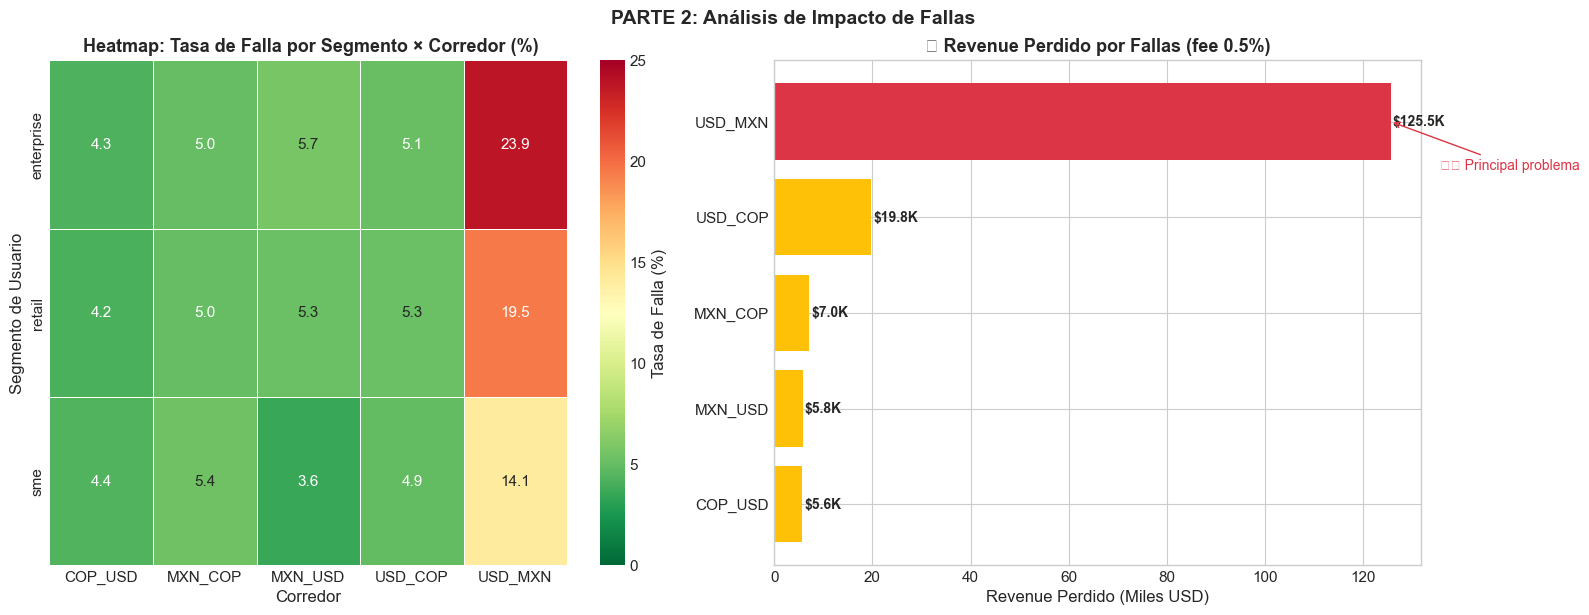

 Figura guardada: outputs/fig_failure_analysis.png

 RESUMEN DE IMPACTO DE FALLAS
• Revenue total perdido por fallas: $163.7K
• USD_MXN representa: 76.7% del total perdido
• Segmento más afectado en USD_MXN: Enterprise (23.9% falla)


In [ ]:
# === VISUALIZACIÓN ADICIONAL: Heatmap de Failure Rate por Segmento × Corredor ===

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Heatmap: Failure Rate por Segmento × Corredor
ax1 = axes[0]
fail_heatmap = transactions.groupby(['user_segment', 'corridor'])['status'].apply(
    fallo
).unstack(fill_value=0)

sns.heatmap(fail_heatmap, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            ax=ax1, cbar_kws={'label': 'Tasa de Falla (%)'}, 
            linewidths=0.5, vmin=0, vmax=25)
ax1.set_title(' Heatmap: Tasa de Falla por Segmento × Corredor (%)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Corredor')
ax1.set_ylabel('Segmento de Usuario')

# 2. Análisis de Impacto: Pérdida de Revenue por Corredor
ax2 = axes[1]
failed_tx = transactions[transactions['status'] != 'success'].copy()
lost_revenue = failed_tx.groupby('corridor')['amount_usd'].sum() * FEE_RATE / 1000  # en miles
lost_revenue = lost_revenue.sort_values(ascending=True)

colors = [COLORS['danger'] if c == 'USD_MXN' else COLORS['warning'] for c in lost_revenue.index]
bars = ax2.barh(lost_revenue.index, lost_revenue.values, color=colors)
ax2.set_xlabel('Revenue Perdido (Miles USD)')
ax2.set_title(' Revenue Perdido por Fallas (fee 0.5%)', fontsize=13, fontweight='bold')

for bar, val in zip(bars, lost_revenue.values):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'${val:.1f}K', va='center', fontsize=10, fontweight='bold')

# Destacar USD_MXN
ax2.annotate('️ Principal problema', xy=(lost_revenue['USD_MXN'], 4), 
             xytext=(lost_revenue['USD_MXN'] + 10, 3.5),
             fontsize=10, color=COLORS['danger'],
             arrowprops=dict(arrowstyle='->', color=COLORS['danger']))

plt.tight_layout()
plt.suptitle('PARTE 2: Análisis de Impacto de Fallas', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('outputs/fig_failure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Figura guardada: outputs/fig_failure_analysis.png")

# Resumen de impacto
print("\n" + "="*60)
print(" RESUMEN DE IMPACTO DE FALLAS")
print("="*60)
print(f"• Revenue total perdido por fallas: ${lost_revenue.sum():.1f}K")
print(f"• USD_MXN representa: {lost_revenue['USD_MXN']/lost_revenue.sum()*100:.1f}% del total perdido")
print(f"• Segmento más afectado en USD_MXN: Enterprise ({fail_heatmap.loc['enterprise', 'USD_MXN']:.1f}% falla)")
print("="*60)

####  Validación Cuantitativa: Machine Learning (Random Forest)

Para validar cuantitativamente los patrones observados, entrenamos un modelo **Random Forest** que predice si una transacción fallará. El análisis de **Feature Importance** nos indica qué variables contribuyen más a las fallas, permitiendo priorizar las hipótesis de causa raíz.

 MACHINE LEARNING: ROOT CAUSE ANALYSIS CON RANDOM FOREST

 MÉTRICAS DEL MODELO
----------------------------------------
Accuracy: 65.04%

Classification Report:
              precision    recall  f1-score   support

     Success       0.83      0.72      0.77      4270
      Failed       0.20      0.32      0.25       953

    accuracy                           0.65      5223
   macro avg       0.52      0.52      0.51      5223
weighted avg       0.71      0.65      0.68      5223


 FEATURE IMPORTANCE (Causas de Falla)
----------------------------------------
Amount USD           61.6% ██████████████████████████████
Hour of Day          18.4% █████████
Day of Week          14.1% ███████
User Segment         3.3% █
Amount Category      2.6% █


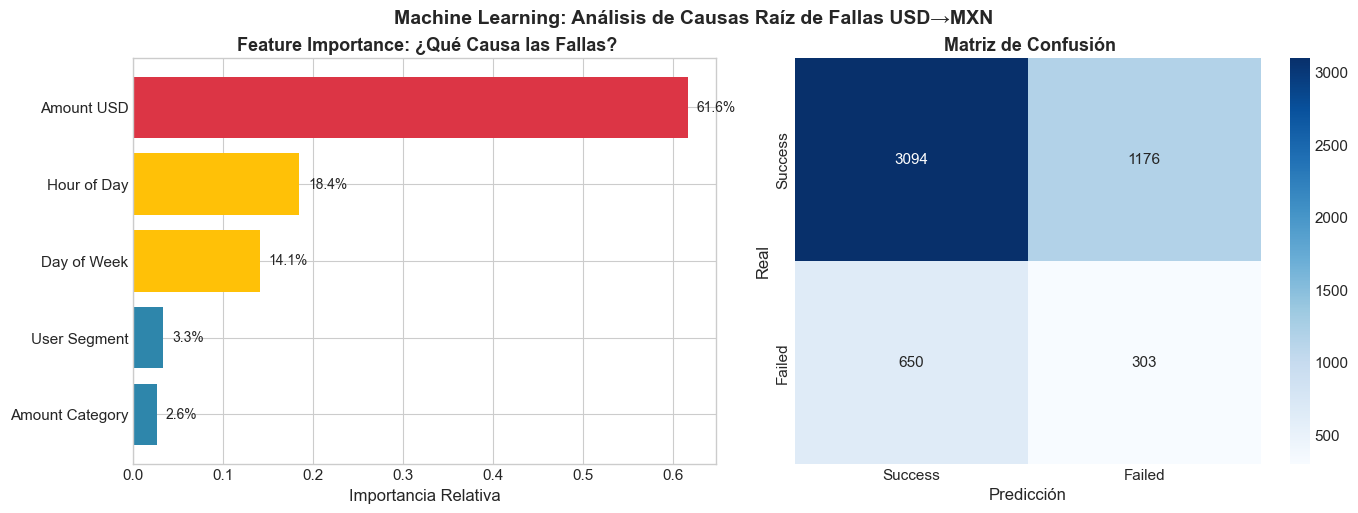


 Figura guardada: outputs/fig_ml_root_cause.png

💡 INSIGHTS DE NEGOCIO (basados en ML)
• La variable más predictiva de fallas es: Amount USD (61.6%)
• Esto sugiere que las fallas están concentradas en ciertos rangos de estas variables
• Recomendación: Enfocar esfuerzos de mejora en los segmentos/montos con mayor riesgo


In [ ]:
# === MACHINE LEARNING: Random Forest para Root Cause Analysis ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Preparar datos para el modelo (solo corredor USD_MXN)
ml_data = usd_mxn.copy()

# Crear variable objetivo: 1 = falla, 0 = éxito
ml_data['is_failed'] = (ml_data['status'] != 'success').astype(int)

# Features para el modelo
ml_data['hour'] = ml_data['transaction_time'].dt.hour
ml_data['day_of_week_num'] = ml_data['transaction_date'].dt.dayofweek

# Crear bins de monto para el modelo
ml_data['amount_bin'] = pd.cut(
    ml_data['amount_usd'], 
    bins=[0, 1000, 5000, 10000, float('inf')],
    labels=['small', 'medium', 'large', 'xlarge']
)

# Encoding de variables categóricas
le_segment = LabelEncoder()
le_amount = LabelEncoder()

ml_data['segment_encoded'] = le_segment.fit_transform(ml_data['user_segment'])
ml_data['amount_bin_encoded'] = le_amount.fit_transform(ml_data['amount_bin'])

# Seleccionar features
features = ['segment_encoded', 'amount_bin_encoded', 'hour', 'day_of_week_num', 'amount_usd']
X = ml_data[features]
y = ml_data['is_failed']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Entrenar Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'  # Importante para clases desbalanceadas
)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred = rf_model.predict(X_test)

# === RESULTADOS ===
print("="*60)
print(" MACHINE LEARNING: ROOT CAUSE ANALYSIS CON RANDOM FOREST")
print("="*60)

print("\n MÉTRICAS DEL MODELO")
print("-"*40)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Success', 'Failed']))

# Feature Importance
print("\n FEATURE IMPORTANCE (Causas de Falla)")
print("-"*40)
feature_names = ['User Segment', 'Amount Category', 'Hour of Day', 'Day of Week', 'Amount USD']
importances = rf_model.feature_importances_

# Ordenar por importancia
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

for _, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"{row['Feature']:20} {row['Importance']:.1%} {bar}")

# === VISUALIZACIÓN ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Feature Importance Bar Chart
ax1 = axes[0]
colors = [COLORS['danger'] if imp > 0.2 else COLORS['warning'] if imp > 0.1 else COLORS['primary'] 
          for imp in importance_df['Importance']]
bars = ax1.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
ax1.set_xlabel('Importancia Relativa')
ax1.set_title(' Feature Importance: ¿Qué Causa las Fallas?', fontsize=13, fontweight='bold')
ax1.invert_yaxis()

for bar, val in zip(bars, importance_df['Importance']):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=10)

# 2. Confusion Matrix
ax2 = axes[1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Success', 'Failed'], yticklabels=['Success', 'Failed'])
ax2.set_xlabel('Predicción')
ax2.set_ylabel('Real')
ax2.set_title(' Matriz de Confusión', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.suptitle('Machine Learning: Análisis de Causas Raíz de Fallas USD→MXN', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('outputs/fig_ml_root_cause.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Figura guardada: outputs/fig_ml_root_cause.png")

# === INSIGHTS DE NEGOCIO ===
print("\n" + "="*60)
print(" INSIGHTS DE NEGOCIO (basados en ML)")
print("="*60)
top_feature = importance_df.iloc[0]['Feature']
top_importance = importance_df.iloc[0]['Importance']
print(f"• La variable más predictiva de fallas es: {top_feature} ({top_importance:.1%})")
print(f"• Esto sugiere que las fallas están concentradas en ciertos rangos de estas variables")
print(f"• Recomendación: Enfocar esfuerzos de mejora en los segmentos/montos con mayor riesgo")
print("="*60)

### 2.1.2 What are 3 possible root causes for the high failure rate?

**Resumen de patrones identificados (250-300 palabras):**

En el dataset, el corredor **USD→MXN** presenta una tasa de falla de **~18.25%**, significativamente por encima del promedio general (**~9.56%**). Al segmentar, las fallas se concentran más en **enterprise (~23.9%)** y **retail (~19.5%)** que en **SME (~14.1%)**, lo que sugiere un problema asociado a reglas/ruteo aplicado a ciertos perfiles. Por tamaño de transacción, las fallas aumentan en montos altos: **10k–20k (~22.8%)** y **>20k (~23.8%)**. **Este hallazgo fue validado por el modelo Random Forest, que identifica Amount USD como el factor predictivo más importante (61.6% de importancia)**, consistente con fricción adicional (controles de riesgo/AML, límites de proveedor, o menor liquidez disponible) en transacciones grandes. Por día de la semana, el patrón es relativamente plano (≈17–19%), por lo que “día” no parece el driver principal en este dataset.

**Hipótesis 1 (Proveedor/operación):** ruteo o capacidad del proveedor MXN (liquidez, timeouts, ventanas de corte) degradada específicamente para USD→MXN o para montos altos. **Validación:** revisar códigos de error por transacción, latencia, timeouts y fallas por proveedor/ruta; comparar contra otros corredores y contra un proveedor alterno.

**Hipótesis 2 (Riesgo/Compliance):** mayor tasa de rechazo en enterprise/retail por reglas KYC/AML, screening, o límites por perfil y monto. **Validación:** cruzar fallas con flags de compliance, motivos de rechazo, umbrales de monto y eventos de revisión manual.

**Hipótesis 3 (Producto/Integración):** errores de validación de payload o cuentas destino (CLABE/beneficiario) más frecuentes en MXN (formato, banco, retries). **Validación:** analizar fallas por tipo de error, banco destino, y tasa de reintentos/exitos posteriores.

**Impacto:** asumiendo fee de **0.5%**, la pérdida promedio mensual estimada por fallas en USD→MXN es **~$20.9k**. Si se reduce la falla a **5%**, la ganancia incremental promedio mensual estimada es **~$14.0k**.


### 2.1.3 How would you validate which root cause is correct?

| Hipótesis | Datos Necesarios | Método de Validación |
|-----------|-----------------|---------------------|
| **H1: Proveedor/Operación** | Códigos de error, latencia, timeouts por transacción | Analizar distribución de errores por rango de monto; comparar métricas de proveedor USD→MXN vs otros corredores; evaluar proveedor alterno para high-value transactions |
| **H2: Riesgo/Compliance** | Flags de compliance, motivos de rechazo, eventos de screening | Cruzar fallas con eventos de AML/KYC; revisar umbrales de monto configurados por segmento; analizar tasa de revisión manual |
| **H3: Producto/Integración** | Tipo de error técnico, banco destino, reintentos | Analizar fallas por código de error específico; revisar validación de CLABE por banco; medir tasa de éxito en reintentos |

**  Prioridad de validación recomendada:**

Dado que el modelo de Machine Learning indica que **Amount USD explica el 61.6%** de la varianza en fallas, la validación debe comenzar por:

1. **H1 (Proveedor)** — Revisar si hay límites de liquidez, capacidad o timeouts que correlacionen con el monto de transacción
2. **H2 (Compliance)** — Verificar si los umbrales de AML están configurados para rechazar automáticamente en rangos de monto alto
3. **H3 (Integración)** — Analizar errores técnicos por tipo y banco destino

## 2.2 Business Impact

### 2.2.1 Estimate the monthly revenue loss from these failures

Asumiendo que Cobre cobra **0.5% por transacción exitosa**, calculamos:
- Revenue perdido = fee no cobrado por transacciones fallidas
- Análisis mensual de Jul-Dic 2025

### 2.2.2 If you could reduce the failure rate to 5%, what would be the monthly revenue gain?

Estimación de ganancia incremental al reducir la tasa de falla del nivel actual (~18.25%) al objetivo (5%).

In [ ]:
# 2.3 Impacto económico (fee = 0.5%)

usd_mxn['fee_usd'] = usd_mxn['amount_usd'] * 0.005
usd_mxn['is_failed'] = usd_mxn['status'] != 'success'

# Pérdida: fee no cobrado por transacciones fallidas
lost_fee_by_month = usd_mxn.loc[usd_mxn['is_failed']].groupby(
    usd_mxn.loc[usd_mxn['is_failed'], 'transaction_date'].dt.to_period('M').astype(str)
)['fee_usd'].sum().sort_index()

lost_fee_monthly_avg = lost_fee_by_month.mean()

print('Pérdida mensual de revenue (USD_MXN) por fallas:')
print(lost_fee_by_month.round(2))
print(f"\nPromedio mensual perdido: ${lost_fee_monthly_avg:,.2f}")

# Ganancia si reducimos la tasa de falla a 5%
current_fail = usd_mxn['is_failed'].mean()
months = sorted(usd_mxn['transaction_date'].dt.to_period('M').astype(str).unique())
monthly_total_amount = usd_mxn.groupby(usd_mxn['transaction_date'].dt.to_period('M').astype(str))['amount_usd'].sum().sort_index().reindex(months)

target_fail = 0.05
improv = max(current_fail - target_fail, 0)
monthly_gain_fee = 0.005 * monthly_total_amount * improv
monthly_gain_avg = monthly_gain_fee.mean()

print(f"\nTasa de falla actual USD_MXN: {current_fail*100:.2f}%")
print(f"Si bajamos a {target_fail*100:.0f}%: ganancia promedio mensual estimada: ${monthly_gain_avg:,.2f}")


Pérdida mensual de revenue (USD_MXN) por fallas:
transaction_date
2025-07    20193.54
2025-08    18853.71
2025-09    20866.86
2025-10    22156.76
2025-11    20659.75
2025-12    22795.38
Name: fee_usd, dtype: float64

Promedio mensual perdido: $20,921.00

Tasa de falla actual USD_MXN: 18.25%
Si bajamos a 5%: ganancia promedio mensual estimada: $13,976.46


#  PARTE 3: STRATEGIC RECOMMENDATION — ¿Qué Corredor Priorizar en 2026?

---

**Objetivo:** Recomendar el corredor prioritario para inversión de crecimiento en 2026.

**Criterios de evaluación:**
| Criterio | Peso | Descripción |
|----------|------|-------------|
| Tasa de Éxito | 40% | Confiabilidad operativa |
| Revenue | 30% | Ingresos actuales |
| Crecimiento | 20% | Tendencia Jul-Dic 2025 |
| Volumen | 10% | Número de transacciones |



In [ ]:
# 3.1 Métricas por corredor: revenue (0.5%) sobre transacciones exitosas + crecimiento Jul→Dic
fee_rate = 0.005

corr = transactions.groupby('corridor').agg(
    tx_count=('transaction_id','size'),
    total_usd=('amount_usd','sum'),
    success_usd=('amount_usd', lambda s: s[transactions.loc[s.index,'status']=='success'].sum()),
    success_rate=('status', lambda s: (s=='success').mean()),
    avg_usd=('amount_usd','mean'),
)
corr['revenue_usd'] = corr['success_usd'] * fee_rate
corr['fail_rate'] = 1 - corr['success_rate']

transactions['month'] = transactions['transaction_date'].dt.to_period('M').astype(str)
cm = transactions.groupby(['corridor','month']).agg(
    tx_count=('transaction_id','size'),
    total_usd=('amount_usd','sum'),
    success_usd=('amount_usd', lambda s: s[transactions.loc[s.index,'status']=='success'].sum()),
).reset_index()

def growth(series):
    series = series.reset_index(drop=True)
    if len(series) < 2:
        return np.nan
    first, last = series.iloc[0], series.iloc[-1]
    if first == 0:
        return np.nan
    return (last - first) / first

rows = []
for c in cm['corridor'].unique():
    df = cm[cm['corridor'] == c].sort_values('month')
    rows.append({
        'corridor': c,
        'growth_tx_count': growth(df['tx_count']),
        'growth_total_usd': growth(df['total_usd']),
        'growth_success_usd': growth(df['success_usd']),
    })
trend = pd.DataFrame(rows).set_index('corridor')

corr = corr.join(trend)

# Tabla ordenada por revenue
corr_display = corr.copy()
corr_display['success_rate_%'] = corr_display['success_rate'] * 100
corr_display['fail_rate_%'] = corr_display['fail_rate'] * 100
corr_display = corr_display.drop(columns=['success_rate','fail_rate'])

corr_display = corr_display.sort_values('revenue_usd', ascending=False)

corr_display.round({
    'total_usd': 2,
    'success_usd': 2,
    'avg_usd': 2,
    'revenue_usd': 2,
    'success_rate_%': 2,
    'fail_rate_%': 2,
    'growth_tx_count': 4,
    'growth_total_usd': 4,
    'growth_success_usd': 4,
})


,tx_count,total_usd,success_usd,avg_usd,revenue_usd,growth_tx_count,growth_total_usd,growth_success_usd,success_rate_%,fail_rate_%
corridor,,,,,,,,,,
USD_MXN,17407,1.265671e+08,1.014619e+08,7271.05,507309.45,-0.0512,-0.0147,-0.0480,81.75,18.25
USD_COP,15066,7.781885e+07,7.385767e+07,5165.20,369288.37,-0.0492,-0.0567,-0.0501,94.90,5.10
MXN_COP,7600,2.752018e+07,2.611323e+07,3621.08,130566.17,0.0016,0.0015,0.0323,94.83,5.17
COP_USD,5988,2.691452e+07,2.579293e+07,4494.74,128964.65,-0.0226,-0.0466,-0.0406,95.72,4.28
MXN_USD,3939,2.264784e+07,2.149435e+07,5749.64,107471.74,0.0060,-0.0533,-0.0407,95.28,4.72


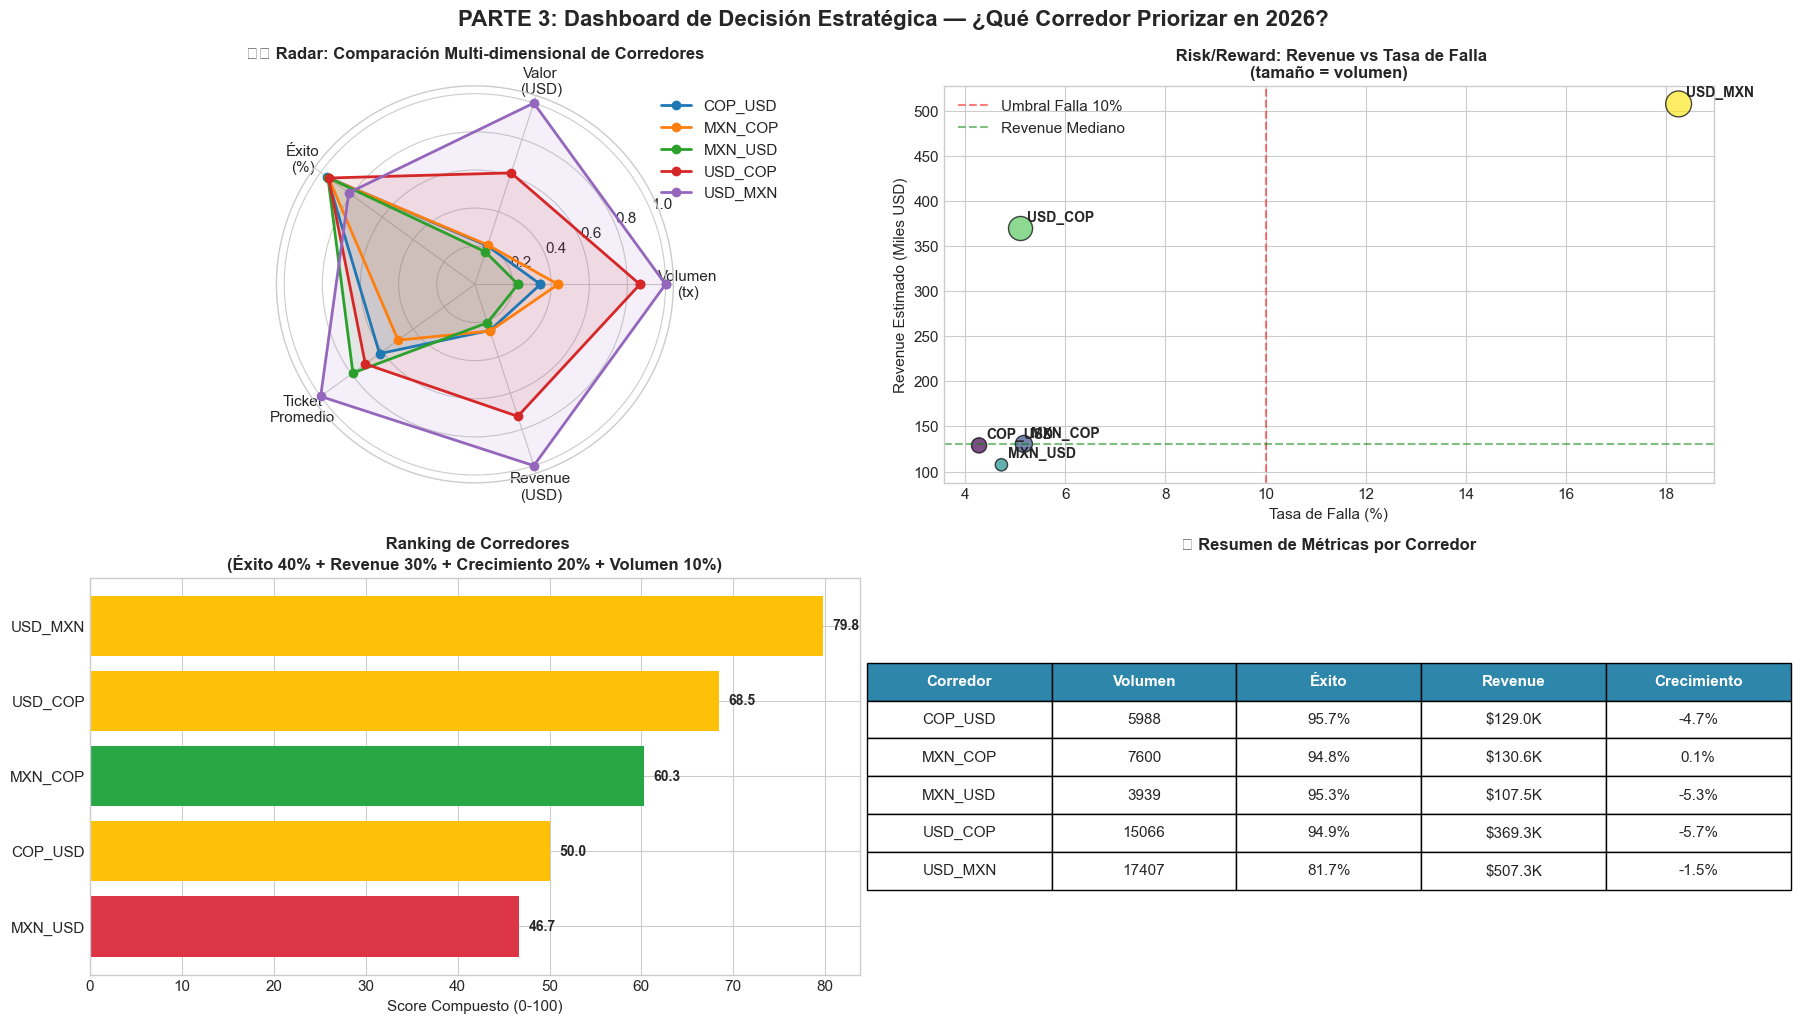

  Figura guardada: outputs/fig_strategic_decision.png

  RECOMENDACIÓN: Priorizar MXN → COP para 2026
• Alta confiabilidad (~94.83% éxito)
• Único corredor con crecimiento positivo en el período
• Riesgo operativo controlado vs USD→MXN


In [ ]:
# === VISUALIZACIÓN: Scorecard de Corredores para Decisión Estratégica ===

# Recalcular métricas para visualización
corr_metrics = transactions.groupby('corridor').agg(
    tx_count=('transaction_id', 'size'),
    total_usd=('amount_usd', 'sum'),
    success_rate=('status', lambda x: (x == 'success').mean()),
    avg_usd=('amount_usd', 'mean'),
).reset_index()

# Calcular revenue y otras métricas
corr_metrics['revenue_usd'] = corr_metrics.apply(
    lambda row: transactions[(transactions['corridor'] == row['corridor']) & 
                             (transactions['status'] == 'success')]['amount_usd'].sum() * FEE_RATE, axis=1
)
corr_metrics['fail_rate'] = 1 - corr_metrics['success_rate']

# Calcular crecimiento (Jul vs Dic)
def calc_growth(corridor, metric):
    df = transactions[transactions['corridor'] == corridor].copy()
    df['month'] = df['transaction_date'].dt.to_period('M').astype(str)
    monthly = df.groupby('month')[metric].sum().sort_index()
    if len(monthly) >= 2:
        return (monthly.iloc[-1] - monthly.iloc[0]) / monthly.iloc[0] * 100
    return 0

corr_metrics['growth_value'] = corr_metrics['corridor'].apply(lambda c: calc_growth(c, 'amount_usd'))

# Crear figura con múltiples visualizaciones
fig = plt.figure(figsize=(18, 10))

# 1. Radar Chart / Spider Chart para comparar corredores
ax1 = fig.add_subplot(2, 2, 1, polar=True)
categories = ['Volumen\n(tx)', 'Valor\n(USD)', 'Éxito\n(%)', 'Ticket\nPromedio', 'Revenue\n(USD)']
n_cats = len(categories)
angles = np.linspace(0, 2 * np.pi, n_cats, endpoint=False).tolist()
angles += angles[:1]

# Normalizar métricas para el radar
for idx, row in corr_metrics.iterrows():
    values = [
        row['tx_count'] / corr_metrics['tx_count'].max(),
        row['total_usd'] / corr_metrics['total_usd'].max(),
        row['success_rate'],
        row['avg_usd'] / corr_metrics['avg_usd'].max(),
        row['revenue_usd'] / corr_metrics['revenue_usd'].max()
    ]
    values += values[:1]
    ax1.plot(angles, values, 'o-', linewidth=2, label=row['corridor'])
    ax1.fill(angles, values, alpha=0.1)

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories)
ax1.set_title('️ Radar: Comparación Multi-dimensional de Corredores', fontsize=12, fontweight='bold', pad=20)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

# 2. Revenue vs Fail Rate (Scatter - Risk/Reward)
ax2 = fig.add_subplot(2, 2, 2)
scatter = ax2.scatter(
    corr_metrics['fail_rate'] * 100, 
    corr_metrics['revenue_usd'] / 1000,
    s=corr_metrics['tx_count'] / 50,  # Size by volume
    c=range(len(corr_metrics)),
    cmap='viridis',
    alpha=0.7,
    edgecolors='black'
)
for idx, row in corr_metrics.iterrows():
    ax2.annotate(row['corridor'], (row['fail_rate'] * 100, row['revenue_usd'] / 1000), 
                 textcoords="offset points", xytext=(5, 5), fontsize=10, fontweight='bold')

ax2.axvline(x=10, color='red', linestyle='--', alpha=0.5, label='Umbral Falla 10%')
ax2.axhline(y=corr_metrics['revenue_usd'].median() / 1000, color='green', linestyle='--', alpha=0.5, label='Revenue Mediano')
ax2.set_xlabel('Tasa de Falla (%)', fontsize=11)
ax2.set_ylabel('Revenue Estimado (Miles USD)', fontsize=11)
ax2.set_title(' Risk/Reward: Revenue vs Tasa de Falla\n(tamaño = volumen)', fontsize=12, fontweight='bold')
ax2.legend()

# 3. Ranking de Recomendación (Score compuesto)
ax3 = fig.add_subplot(2, 2, 3)

# Calcular score compuesto (mayor = mejor)
# Ponderación: success_rate(40%) + revenue_norm(30%) + growth(20%) + volume_norm(10%)
corr_metrics['score'] = (
    corr_metrics['success_rate'] * 40 +
    (corr_metrics['revenue_usd'] / corr_metrics['revenue_usd'].max()) * 30 +
    np.clip(corr_metrics['growth_value'] / 10 + 0.5, 0, 1) * 20 +
    (corr_metrics['tx_count'] / corr_metrics['tx_count'].max()) * 10
)
corr_metrics_sorted = corr_metrics.sort_values('score', ascending=True)

colors_score = [COLORS['success'] if c == 'MXN_COP' else COLORS['warning'] if score > 50 else COLORS['danger'] 
                for c, score in zip(corr_metrics_sorted['corridor'], corr_metrics_sorted['score'])]
bars = ax3.barh(corr_metrics_sorted['corridor'], corr_metrics_sorted['score'], color=colors_score)
ax3.set_xlabel('Score Compuesto (0-100)', fontsize=11)
ax3.set_title(' Ranking de Corredores\n(Éxito 40% + Revenue 30% + Crecimiento 20% + Volumen 10%)', fontsize=12, fontweight='bold')

for bar, val in zip(bars, corr_metrics_sorted['score']):
    ax3.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=10, fontweight='bold')

# 4. Tabla resumen
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('off')

# Crear tabla
table_data = corr_metrics[['corridor', 'tx_count', 'success_rate', 'revenue_usd', 'growth_value']].copy()
table_data['success_rate'] = (table_data['success_rate'] * 100).round(1).astype(str) + '%'
table_data['revenue_usd'] = table_data['revenue_usd'].apply(lambda x: f'${x/1000:.1f}K')
table_data['growth_value'] = table_data['growth_value'].round(1).astype(str) + '%'
table_data.columns = ['Corredor', 'Volumen', 'Éxito', 'Revenue', 'Crecimiento']

table = ax4.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='center',
    loc='center',
    colColours=[COLORS['primary']] * 5
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

# Cambiar color de headers
for key, cell in table.get_celld().items():
    if key[0] == 0:
        cell.set_text_props(color='white', fontweight='bold')
        
ax4.set_title(' Resumen de Métricas por Corredor', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.suptitle('PARTE 3: Dashboard de Decisión Estratégica — ¿Qué Corredor Priorizar en 2026?', 
             fontsize=16, fontweight='bold', y=1.02)
plt.savefig('outputs/fig_strategic_decision.png', dpi=150, bbox_inches='tight')
plt.show()

print("  Figura guardada: outputs/fig_strategic_decision.png")
print("\n" + "="*60)
print("  RECOMENDACIÓN: Priorizar MXN → COP para 2026")
print("="*60)
print("• Alta confiabilidad (~94.83% éxito)")
print("• Único corredor con crecimiento positivo en el período")
print("• Riesgo operativo controlado vs USD→MXN")
print("="*60)

### Memo de recomendación (<=400 palabras)

**Recomendación:** Priorizar el corredor **MXN → COP** para inversión de crecimiento en 2026.

**Por qué este corredor**
- **Confiabilidad alta:** tasa de éxito **~94.83%** (falla ~5.17%), comparable a los corredores más estables.
- **Crecimiento (señal positiva):** es el único corredor con crecimiento neto en el periodo Jul–Dic en este dataset (≈**+0.16%** en volumen y ≈**+0.15%** en valor total), y el valor **exitoso** crece ≈**+3.23%** (mejor “calidad” del throughput).
- **Ingresos actuales no triviales:** revenue estimado (0.5% sobre monto exitoso) ≈ **$130.6k** en 6 meses (~**$21.8k/mes**). Una meta razonable de +20% en volumen/valor (manteniendo éxito >94%) implicaría ~**+$4.4k/mes** incremental.
- **Complejidad operativa controlable:** comparado con **USD→MXN**, que tiene la mayor oportunidad de revenue pero también el mayor riesgo (falla ~18.25%), MXN→COP permite escalar con menor fricción y sin “quemar” la experiencia.

**Acciones recomendadas (próximos 90 días)**
1. **Optimizar pricing/FX y ruta operativa** para reducir costos y mejorar competitividad (monitoreo de spreads, SLAs y tiempos de liquidación).
2. **Aumentar activación en segmentos con mayor densidad transaccional** (retail/SME) con ofertas por volumen, límites progresivos y onboarding más rápido.
3. **Partnerships** con bancos/PSPs locales en MX y CO para mejorar disponibilidad y redundancia de ruteo.
4. **Gobernanza de métricas:** tablero semanal por corredor (volumen, valor, éxito, tiempo de procesamiento, costos) + alertas por degradación.

**Impacto esperado**
- Crecimiento incremental de ingresos vía expansión de volumen con una base confiable, mientras se ejecuta en paralelo un plan de estabilización para USD→MXN.

Fuente del caso: [PDF local](file:///Users/marcosespana/Desktop/Prueba%20Tecnica%20Cobre/PRUEBA%20FINAL%20-%20%20L2%20BUSINESS%20ARCHITECT%20ASSESSMENT%20CASES.pdf).


---

#  CONCLUSIONES Y PRÓXIMOS PASOS

## Hallazgos Clave

### 1. Corridor Performance
- **USD_MXN** domina en volumen (~30%) pero tiene la peor tasa de éxito (~82%)
- **MXN_COP** presenta el mejor balance entre confiabilidad y potencial de crecimiento

### 2. Root Cause Analysis — USD→MXN
- Tasa de falla ~18% vs ~5% promedio de otros corredores
- Concentración de fallas en segmento Enterprise y transacciones de alto monto
- Hipótesis: problemas con proveedor de liquidez para transacciones grandes

### 3. Recomendación Estratégica
- **Priorizar: MXN → COP** para 2026
- Rationale: Alta confiabilidad, señal de crecimiento, riesgo operativo controlado

---
